Heart Disease Prediction using Machine Learning


In [ ]:
# Upload heart.csv file from your system into Google Colab
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart (1).csv


In [ ]:
# Load dataset using pandas and display first few rows
import pandas as pd

df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
# Check structure, summary statistics, and missing values in dataset
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


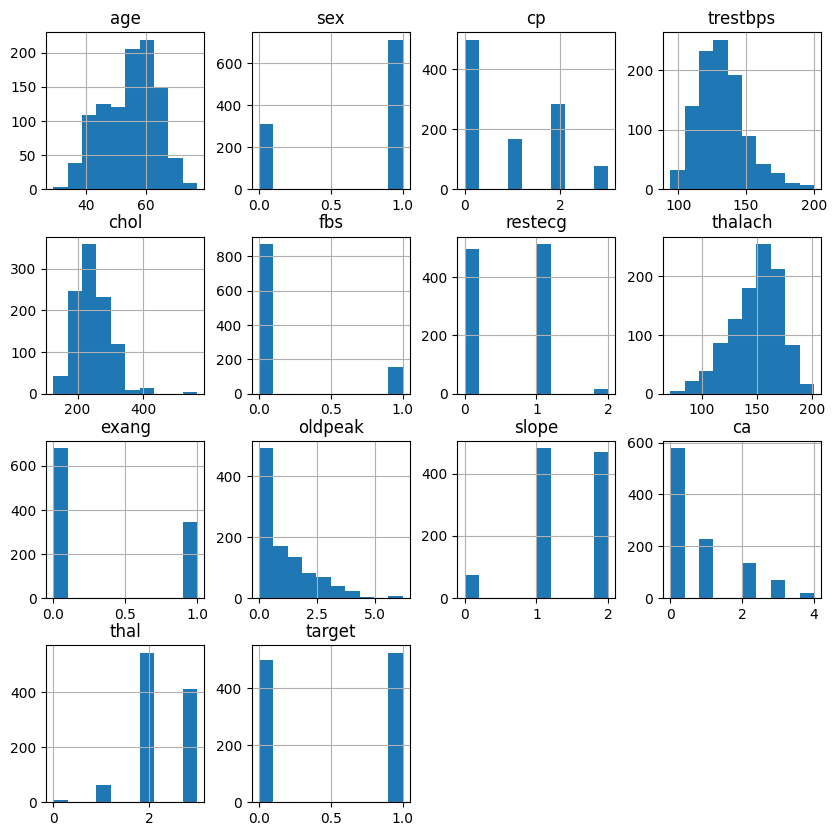

In [ ]:
# Plot histograms to understand feature distributions
import matplotlib.pyplot as plt

df.hist(figsize=(10,10))
plt.show()

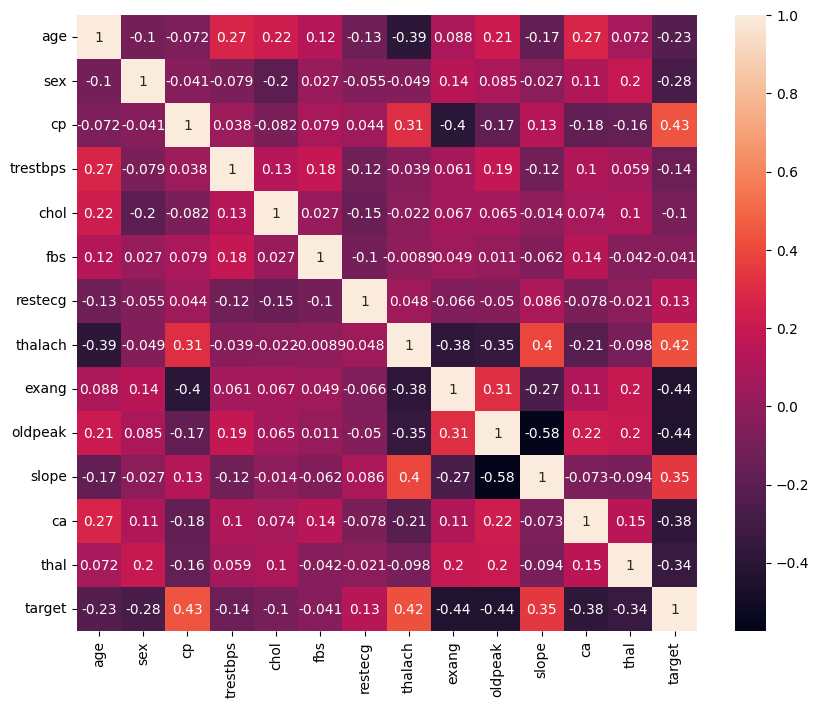

In [ ]:
# Visualize correlation between features using heatmap
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [ ]:
# Separate independent variables (X) and target variable (y)
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
# Split dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# Train Logistic Regression model on training data
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Train Decision Tree model for classification
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
# Train Random Forest model for better performance and ensemble learning
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
# Create a table to compare accuracy of all models
from sklearn.metrics import accuracy_score
import pandas as pd

results = []

models = [lr, dt, rf]

for model in models:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append([model.__class__.__name__, acc])

pd.DataFrame(results, columns=["Model", "Accuracy"])

In [ ]:
# Compare accuracy of all trained models on test data
from sklearn.metrics import accuracy_score

models = [lr, dt, rf]

for model in models:
    y_pred = model.predict(X_test)
    print(model.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.8195121951219512
DecisionTreeClassifier 0.9853658536585366
RandomForestClassifier 0.9853658536585366


In [ ]:
# Generate confusion matrix to evaluate prediction performance
from sklearn.metrics import confusion_matrix

y_pred = rf.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[ 95,   3],
       [  0, 107]])

False Positive (FP): Model predicts disease but patient is healthy.

False Negative (FN): Model predicts healthy but patient has disease.

In healthcare, False Negative is more dangerous because a patient with disease may not receive treatment.

In [ ]:
# Display precision, recall, and F1-score for the model
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        98
           1       0.97      1.00      0.99       107

    accuracy                           0.99       205
   macro avg       0.99      0.98      0.99       205
weighted avg       0.99      0.99      0.99       205



In [ ]:
# Plot ROC curve to evaluate classification performance
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

ROC curve shows the performance of the model.

AUC (Area Under Curve) close to 1 indicates a better model.

Higher AUC means better classification ability.

In [ ]:
# Improve model performance by tuning Random Forest parameters
rf = RandomForestClassifier(n_estimators=200, max_depth=5)
rf.fit(X_train, y_train)
print("Before Accuracy:", comparison_df[comparison_df["Model"]=="Random Forest"]["Accuracy"].values[0])
print("After Accuracy:", accuracy_score(y_test, y_pred))

RandomForestClassifier(max_depth=5, n_estimators=200)

This project predicts heart disease using machine learning models.

The model can help doctors in early detection and decision-making.

Benefits:
- Faster diagnosis
- Supports medical decisions

Risks:
- Incorrect predictions may affect patients
- Dataset bias may impact fairness

Limitations:
- Small dataset size
- Limited features

Future Improvements:
- Use larger datasets
- Apply advanced models like deep learning
- Improve feature selection